# Random FDLU noising single layer single site

Created: 24-06-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising_single_layer.ipynb), but now compose single layer of single site gates.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

In [6]:
from scipy.stats import ortho_group

In [7]:
from collections import Counter

In [8]:
import pandas as pd

# Definitions
## Groundstates

In [9]:
num_sites = 16

In [10]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [11]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [12]:
parameters = np.linspace(0, 1, 11)

In [13]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [14]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:14<00:00,  1.36s/it]


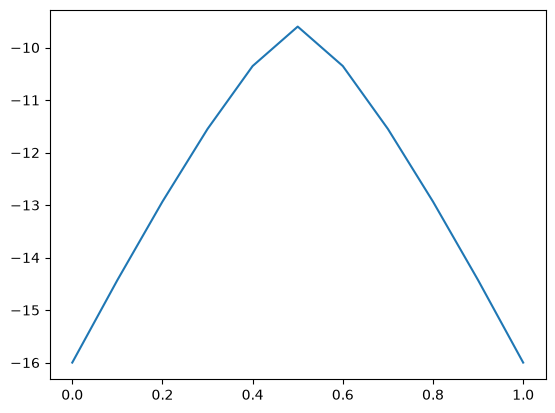

In [15]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [16]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [17]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [18]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [19]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [20]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [21]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [22]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [23]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [24]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [25]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [26]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [27]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [28]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [29]:
def get_tensor_network_factorization(qt_rho, rho_purity):
    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [30]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [31]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [32]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [33]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [34]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [35]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [36]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [37]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [38]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {k: (4,4) for k in unfuse_map.keys()}

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [39]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    rho.contract(inplace=True)

    return rho

In [40]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [41]:
def extract_time_reversal_information(psi):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, symmetry_sites)
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': ['k4', 'k5', 'k6', 'k7'],
            'kr': ['k8', 'k9', 'k10', 'k11'],
            'bl': ['b4', 'b5', 'b6', 'b7'],
            'br': ['b8', 'b9', 'b10', 'b11']
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(qt_rho, rho_purity)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [42]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(2)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np_H @ np.diag([1, 1j])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [43]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for i in range(num_sites):
        u = generate_random_symmetry_respecting_unitary()
        
        qu_u = qtn.Tensor(
            u.reshape((2,)*2),
            inds=[f'k{i}', f'b{i}']
        )

        qu_psi = qu_psi.reindex({f'k{i}':  f'b{i}'}) & qu_u
        qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [44]:
def apply_onsite_unitaries_to_quimb_state(psi, unitaries=None):
    if unitaries is None:
        np_unitaries = [
            generate_random_symmetry_respecting_unitary()
            for _ in range(num_sites)
        ]

        unitaries = [
            qtn.Tensor(u, inds=['k', 'b'])
            for u in np_unitaries
        ]

    tn = qtn.TensorNetwork(
        [psi.reindex({f'k{i}': f'b{i}' for i in range(num_sites)}),] +
        [u.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i, u in enumerate(unitaries)],
        virtual=True
    )

    tn.contract(inplace=True)

    return tn

In [45]:
def extract_time_reversal_information_after_random_fdlu(psi, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_onsite_unitaries_to_quimb_state(psi)
        out.append(extract_time_reversal_information(rand_psi))

    return out

In [46]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# Sweep

In [47]:
fixed_point_groundstates = [
    groundstates[0],
    groundstates[-1]
]

In [48]:
quimb_fixed_point_groundstates = [
    get_quimb_psi_from_quspin_psi(psi)
    for psi in fixed_point_groundstates
]

In [49]:
sweep_results = list()

for psi in tqdm(quimb_fixed_point_groundstates):
    l = extract_time_reversal_information_after_random_fdlu(psi, 20)
    sweep_results.append(l)

  0%|                                                                                                                                         | 0/2 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:52<00:00, 26.21s/it]


## Analyse results

### Left right rho schmidt values

#### Trivial

In [50]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[0]
]

In [51]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [52]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [53]:
triv_schmidt_vals

[[np.float64(1.000000000000005)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.0000000000000044)],
 [np.float64(1.000000000000005)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000042)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.0000000000000042)],
 [np.float64(1.0000000000000022)],
 [np.float64(1.000000000000004)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000036)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000027)]]

In [54]:
def get_schmidt_vals_ratio(l):
    if len(l) == 1:
        return 0
    else:
        return l[1]/l[0]

In [55]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [56]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

#### Non-trivial

In [57]:
nontriv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[1]
]

In [58]:
num_nontriv_schmidt_vals = [len(l) for l in nontriv_schmidt_vals]

In [59]:
Counter(num_nontriv_schmidt_vals)

Counter({1: 20})

In [60]:
nontriv_schmidt_vals

[[np.float64(0.25000000000000117)],
 [np.float64(0.25000000000000117)],
 [np.float64(0.2500000000000008)],
 [np.float64(0.25000000000000105)],
 [np.float64(0.2500000000000011)],
 [np.float64(0.250000000000001)],
 [np.float64(0.25000000000000105)],
 [np.float64(0.25000000000000117)],
 [np.float64(0.25000000000000105)],
 [np.float64(0.250000000000001)],
 [np.float64(0.250000000000001)],
 [np.float64(0.2500000000000012)],
 [np.float64(0.250000000000001)],
 [np.float64(0.2500000000000011)],
 [np.float64(0.25000000000000117)],
 [np.float64(0.25000000000000094)],
 [np.float64(0.25000000000000117)],
 [np.float64(0.25000000000000105)],
 [np.float64(0.25000000000000133)],
 [np.float64(0.2500000000000013)]]

In [61]:
nontriv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in nontriv_schmidt_vals
]

In [62]:
pd.Series(nontriv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

All expected.

### Purification full effective density matrix
Output data:
* left_right_singular_vals
* left_defect_op_invariant
* right_defect_op_invariant
* overlaps
* purification_diff_score

#### Trivial

In [63]:
purification_rho_sweep_results = [l[1] for l in sweep_results[0]]

In [64]:
purification_rho_sweep_results[0][0]

array([1.])

In [65]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in purification_rho_sweep_results
]

In [66]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [67]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [68]:
triv_schmidt_vals

[[np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000036)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000042)],
 [np.float64(1.0000000000000047)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000062)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.000000000000006)],
 [np.float64(1.000000000000005)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.000000000000004)],
 [np.float64(1.0000000000000027)],
 [np.float64(1.0000000000000038)],
 [np.float64(1.0000000000000042)],
 [np.float64(1.0000000000000042)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000024)]]

In [69]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [70]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(1.0408340855860843e-16), np.float64(1.1102230246251565e-16))

In [71]:
np.round(left_defect_op_invariants, 3)

array([1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [72]:
np.round(right_defect_op_invariants, 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [73]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [74]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [75]:
overlaps = np.real(overlaps[:, -1])

In [76]:
pd.Series(overlaps).describe()

count    2.000000e+01
mean     1.000000e+00
std      1.145879e-15
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

#### Non-trivial

In [77]:
purification_rho_sweep_results = [l[1] for l in sweep_results[1]]

In [78]:
purification_rho_sweep_results[0][0]

array([0.23794711, 0.07028968, 0.02487715, 0.01793495])

In [79]:
purification_rho_sweep_results[-1][0]

array([0.21215299, 0.12849559, 0.02273579, 0.02151917])

In [80]:
schmidt_vals = [
    [x for x in l[0] if x > 0.0005]
    for l in purification_rho_sweep_results
]

In [81]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [82]:
Counter(num_schmidt_vals)

Counter({4: 20})

In [83]:
purification_rho_sweep_results[0][0]

array([0.23794711, 0.07028968, 0.02487715, 0.01793495])

In [84]:
schmidt_vals

[[np.float64(0.23794710687604592),
  np.float64(0.07028968115322037),
  np.float64(0.02487714927843439),
  np.float64(0.017934951811398456)],
 [np.float64(0.2375989787912712),
  np.float64(0.07765337721447302),
  np.float64(0.003089000197385585),
  np.float64(0.0026713970713686686)],
 [np.float64(0.21518272377054345),
  np.float64(0.12547504574829693),
  np.float64(0.015909719851137243),
  np.float64(0.014116979117769067)],
 [np.float64(0.21252091388146213),
  np.float64(0.12990715993766175),
  np.float64(0.015571010255025547),
  np.float64(0.014715114663410913)],
 [np.float64(0.2426842231140535),
  np.float64(0.05824799988764708),
  np.float64(0.013707963741425692),
  np.float64(0.00486107916838161)],
 [np.float64(0.226001464853638),
  np.float64(0.10536724001693504),
  np.float64(0.014786010621413622),
  np.float64(0.01012208007908583)],
 [np.float64(0.2388142577793573),
  np.float64(0.06517551875679964),
  np.float64(0.024764242518250268),
  np.float64(0.02462994779885857)],
 [np.fl

In [85]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [86]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.463566
std       0.225923
min       0.203953
25%       0.272653
50%       0.409587
75%       0.588751
max       0.998959
dtype: float64

In [87]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [88]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(5.551115123125783e-17), np.float64(8.326672684688674e-17))

In [89]:
np.round(left_defect_op_invariants, 3)

array([-1.-0.j, -1.-0.j, -1.+0.j, -1.-0.j, -1.-0.j, -1.+0.j, -1.+0.j,
       -1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j,
       -1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j])

In [90]:
np.round(right_defect_op_invariants, 3)

array([-1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j,
       -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j,
       -1.+0.j, -1.+0.j, -1.+0.j, -1.-0.j, -1.+0.j, -1.-0.j])

In [91]:
all_overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [92]:
np.max(np.abs(np.imag(all_overlaps)))

np.float64(0.0)

In [93]:
overlaps = np.real(all_overlaps[:, -1])

In [94]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.878100
std       0.119868
min       0.513982
25%       0.858069
50%       0.922017
75%       0.955494
max       0.978855
dtype: float64

In [95]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [96]:
defect_results = defect_results[defect_results[:, 0].argsort()]

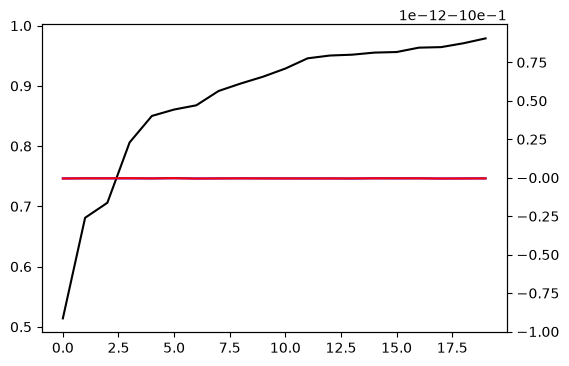

In [97]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [98]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(1.2550771358570979e-30)

So this method is breaking down in the cluster state case...

In [99]:
all_overlaps.shape

(20, 40)

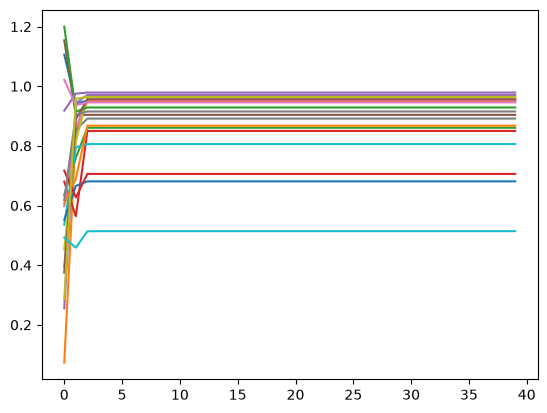

In [100]:
plt.plot(all_overlaps.T);

This makes no sense?

### Purificaiton and defect operators on cut states

#### Trivial

In [101]:
purification_diffs = [l[2] for l in sweep_results[0]]

In [102]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(2.8882271526979162e-30)

In [103]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[0]]

Each list contains:
1. Vertical singular value for that eigenvector
2. Left right singular values for resulting effective density matrix.
3. Left invariant
4. Right invariant
5. Overlaps

In [104]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [105]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [106]:
all_left_indices

[np.complex128(0.9999999999999998+5.551115123125783e-17j),
 np.complex128(0.9999999999999998+4.163336342344337e-17j),
 np.complex128(0.9999999999999999-2.7755575615628914e-17j),
 np.complex128(0.9999999999999996-5.551115123125783e-17j),
 np.complex128(1+5.551115123125783e-17j),
 np.complex128(0.9999999999999998-9.71445146547012e-17j),
 np.complex128(1+1.3877787807814457e-17j),
 np.complex128(1+0j),
 np.complex128(0.9999999999999998+0j),
 np.complex128(1.0000000000000002+1.1102230246251565e-16j),
 np.complex128(1.0000000000000002-1.3877787807814457e-17j),
 np.complex128(1.0000000000000004+8.326672684688674e-17j),
 np.complex128(1.0000000000000004-5.551115123125783e-17j),
 np.complex128(0.9999999999999993+8.326672684688674e-17j),
 np.complex128(1.0000000000000007+0j),
 np.complex128(1+9.71445146547012e-17j),
 np.complex128(0.9999999999999997+0j),
 np.complex128(0.9999999999999996+5.551115123125783e-17j),
 np.complex128(1.0000000000000002-2.7755575615628914e-17j),
 np.complex128(1.0000000

In [107]:
all_right_indices

[np.complex128(1.0000000000000004-5.551115123125783e-17j),
 np.complex128(1.0000000000000004+0j),
 np.complex128(1.0000000000000002-8.326672684688674e-17j),
 np.complex128(1.0000000000000004+0j),
 np.complex128(1.0000000000000004-1.3877787807814457e-17j),
 np.complex128(0.9999999999999994-1.1102230246251565e-16j),
 np.complex128(1+0j),
 np.complex128(1.0000000000000004-5.551115123125783e-17j),
 np.complex128(1+0j),
 np.complex128(1+1.1102230246251565e-16j),
 np.complex128(1-5.551115123125783e-17j),
 np.complex128(1-5.551115123125783e-17j),
 np.complex128(0.9999999999999998-2.7755575615628914e-17j),
 np.complex128(1.0000000000000002-4.163336342344337e-17j),
 np.complex128(1.0000000000000004+8.326672684688674e-17j),
 np.complex128(0.9999999999999999+8.326672684688674e-17j),
 np.complex128(1+0j),
 np.complex128(0.9999999999999992-2.220446049250313e-16j),
 np.complex128(0.9999999999999999+0j),
 np.complex128(0.9999999999999997+4.163336342344337e-17j)]

In [108]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [109]:
all_overlaps

[np.float64(1.0000000000000002),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.0000000000000004),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000004),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999)]

#### Non-trivial

In [110]:
purification_diffs = [l[2] for l in sweep_results[1]]

In [111]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(1.2550771358570979e-30)

In [112]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[1]]

In [113]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [114]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [115]:
all_left_indices

[np.complex128(-1.0000000000000002+0j),
 np.complex128(-0.9949514104378419-0.01005331473976101j),
 np.complex128(-0.793711410712479+0.01607624556968218j),
 np.complex128(-1.0000000000000004+2.0816681711721685e-17j),
 np.complex128(-0.9999999999999999+5.551115123125783e-17j),
 np.complex128(-0.9999999999801957-2.3475665855698935e-13j),
 np.complex128(-0.9999999999999997+0j),
 np.complex128(-0.9999999999999993-5.551115123125783e-17j),
 np.complex128(-1+0j),
 np.complex128(-1.0000000000000002+0j),
 np.complex128(-0.9999999999999999+0j),
 np.complex128(-1+0j),
 np.complex128(-0.9999999999999993+2.7755575615628914e-17j),
 np.complex128(-1.0000000000000002+0j),
 np.complex128(-1.0000000000000004+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999996+5.551115123125783e-17j),
 np.complex128(-1+4.163336342344337e-17j),
 np.complex128(-0.9999999999999996-1.0408340855860843e-17j),
 np.complex128(-1+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999996+2.42861286636753e-17j),
 np.comp

In [116]:
all_right_indices

[np.complex128(-1.0000000000000002+0j),
 np.complex128(-0.9946541814594997+0.010645190239295999j),
 np.complex128(-0.7825598264184329-0.016945298037495796j),
 np.complex128(-1.0000000000000009+1.1102230246251565e-16j),
 np.complex128(-1.0000000000000004+1.1102230246251565e-16j),
 np.complex128(-0.9999999999636598+4.309330670082545e-13j),
 np.complex128(-1.0000000000000007-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999999+0j),
 np.complex128(-1.0000000000000004-5.551115123125783e-17j),
 np.complex128(-1+1.734723475976807e-18j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-1-5.551115123125783e-17j),
 np.complex128(-0.9999999999999998+1.3877787807814457e-17j),
 np.complex128(-1.0000000000000007+0j),
 np.complex128(-1.0000000000000009+5.551115123125783e-17j),
 np.complex128(-0.9999999999999998-4.163336342344337e-17j),
 np.complex128(-0.9999999999999996-2.7755575615628914e-17j),
 np.complex128(-1+0j),
 np.complex128(-0.9999999999999998+3.469446951953614e-18j),
 np.comp

In [117]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [118]:
all_overlaps

[np.float64(1.0000000000000002),
 np.float64(0.9945980301969459),
 np.float64(0.9965173042981306),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(0.9999999999958645),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999998),
 np.float64(0.9999999999999999),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000007),
 np.float64(0.9999999999999997),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000004),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(0.9999999999997295),
 np.float64(0.9999999999999993),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(0.9999999995171954),
 np.float64(0.9999992715969441),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(0.9999999999999998),
 np.flo

### Tensor network factorizations

#### Trivial

In [119]:
factorization_loss_curves = [l[4] for l in sweep_results[0]]

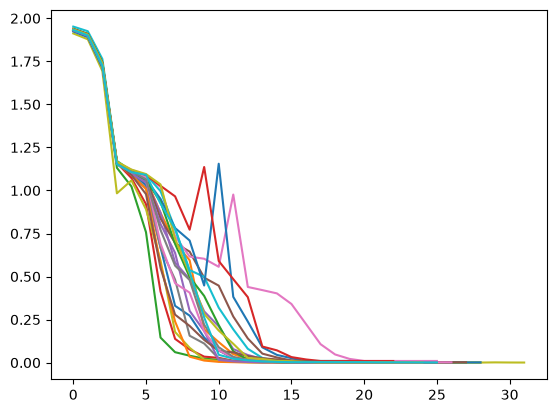

In [120]:
for l in factorization_loss_curves:
    plt.plot(l);

In [121]:
best_loss = [min(l) for l in factorization_loss_curves]

In [122]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.002410
std       0.003148
min       0.000228
25%       0.000648
50%       0.001140
75%       0.002207
max       0.009669
dtype: float64

In [123]:
left_loss = np.array([l[6] for l in sweep_results[0]])
right_loss = np.array([l[7] for l in sweep_results[0]])

In [124]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [125]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [126]:
np.max(left_loss), np.max(right_loss)

(np.float32(9.469885e-12), np.float32(1.1595346e-11))

#### Nontrivial

In [127]:
factorization_loss_curves = [l[4] for l in sweep_results[1]]

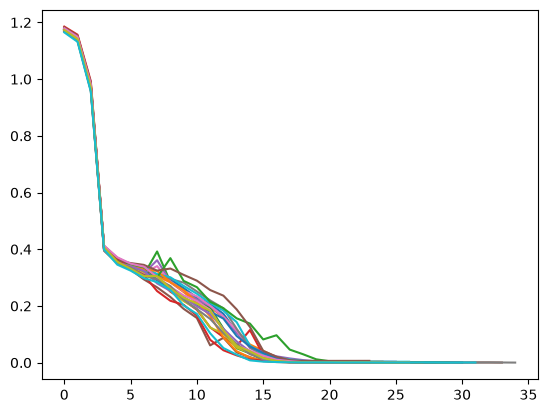

In [128]:
for l in factorization_loss_curves:
    plt.plot(l);

In [129]:
best_loss = [min(l) for l in factorization_loss_curves]

In [130]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.001565
std       0.001599
min       0.000224
25%       0.000461
50%       0.000761
75%       0.002232
max       0.006176
dtype: float64

In [131]:
left_loss = np.array([l[6] for l in sweep_results[1]])
right_loss = np.array([l[7] for l in sweep_results[1]])

In [132]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [133]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [134]:
np.max(left_loss), np.max(right_loss)

(np.float32(2.3986872e-12), np.float32(2.7808478e-12))

### Factorized full effective density matrix

#### Trivial

In [135]:
schmidt_vals = [
    [x for x in l[8] if x > 0.05]
    for l in sweep_results[0]
]

In [136]:
schmidt_vals

[[np.float64(0.9640903261702761)],
 [np.float64(0.9682074459602975)],
 [np.float64(0.9832368489540595)],
 [np.float64(0.9762545248434492)],
 [np.float64(0.9538398222648153)],
 [np.float64(0.9557757606411529)],
 [np.float64(0.9188842173584588)],
 [np.float64(0.9838863049030798)],
 [np.float64(0.9887948774652708)],
 [np.float64(0.916671965913183)],
 [np.float64(0.9767691910969242)],
 [np.float64(0.9775097794780655)],
 [np.float64(0.9751575864645521)],
 [np.float64(0.9236051992039387)],
 [np.float64(0.9710346106215013)],
 [np.float64(0.9548882614254945)],
 [np.float64(0.9616434102048663)],
 [np.float64(0.96249513792427)],
 [np.float64(0.9626277184986678)],
 [np.float64(0.973173136457852)]]

In [137]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [138]:
Counter(num_schmidt_vals)

Counter({1: 20})

In [139]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [140]:
pd.Series(schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [141]:
left_invariants = [l[9] for l in sweep_results[0]]
right_invariants = [l[10] for l in sweep_results[0]]

In [142]:
left_invariants

[np.complex128(1.0000000000000033+5.992323304226943e-11j),
 np.complex128(0.999999999999992-8.472316459506857e-10j),
 np.complex128(1.0000000000000024+1.740985133835693e-11j),
 np.complex128(0.999999999999988+3.95117272233847e-12j),
 np.complex128(1.000000000000001+6.833695831431896e-10j),
 np.complex128(1.0000000000000016+2.6696367338985283e-11j),
 np.complex128(1.0000000000000049-1.2095624501995417e-10j),
 np.complex128(1.0000000000000056-1.3222756223285614e-11j),
 np.complex128(1.000000000000002-4.382105789346724e-12j),
 np.complex128(1.000000000000004+1.1847617331639526e-10j),
 np.complex128(1.0000000000000049-7.735101448247406e-11j),
 np.complex128(1.000000000000004-2.0066379113892197e-12j),
 np.complex128(1-1.0805986661033273e-10j),
 np.complex128(1.0000000000000036+1.7618961845045078e-11j),
 np.complex128(0.9999999999999938+7.997832326966936e-10j),
 np.complex128(1.0000000000000029-5.876019115724773e-11j),
 np.complex128(0.9999999999999971+3.2637953450986856e-10j),
 np.complex12

In [143]:
right_invariants

[np.complex128(1.0000000000000042-3.47284256907443e-10j),
 np.complex128(1.0000000000000016+2.7529700741268925e-11j),
 np.complex128(0.9999999999999962-1.026434492956696e-10j),
 np.complex128(0.9999999999999979-2.451149283544396e-10j),
 np.complex128(0.9999999999999999+1.0287908025485848e-10j),
 np.complex128(1.0000000000000013-2.3044877117683882e-10j),
 np.complex128(1.0000000000000009+1.45950140861828e-10j),
 np.complex128(1.0000000000000047-3.229760903167289e-11j),
 np.complex128(0.9999999999996598+5.220330834276865e-10j),
 np.complex128(1.000000000000003+5.889283505311482e-11j),
 np.complex128(1.0000000000000058-2.6526808527549406e-11j),
 np.complex128(1.000000000000004-5.3364160312874276e-11j),
 np.complex128(1.0000000000000038-8.753192615174044e-12j),
 np.complex128(1.0000000000000022+3.859540465001032e-11j),
 np.complex128(0.9999999999999992+1.1442630176716762e-10j),
 np.complex128(1.0000000000000022+4.958644606034568e-12j),
 np.complex128(1.000000000000003-1.2444334451799932e-1

In [144]:
overlaps = np.array([l[11][-1] for l in sweep_results[0]])

In [145]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [146]:
overlaps = np.real(overlaps)

In [147]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.977045
std       0.011527
min       0.952282
25%       0.971612
50%       0.978308
75%       0.985765
max       0.992640
dtype: float64

In [148]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [149]:
defect_results = defect_results[defect_results[:, 0].argsort()]

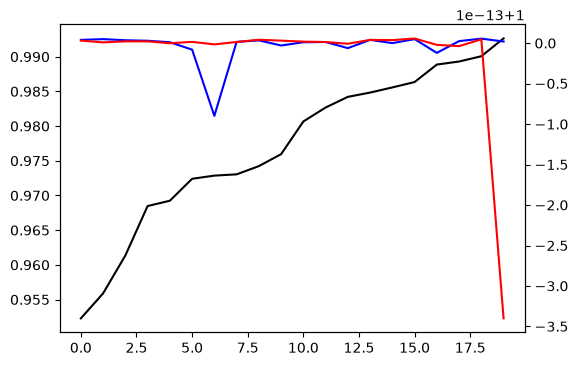

In [150]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

#ax2.set_ylim(-1.05, 1.05)

#### Nontrivial

In [151]:
schmidt_vals = [
    l[8]
    for l in sweep_results[1]
]

In [152]:
schmidt_vals

[array([2.36975333e-01, 2.47290538e-03, 1.46264391e-03, 6.50439235e-04,
        6.12341280e-04, 3.99717404e-04, 2.43661866e-04, 1.50384533e-04,
        1.09308900e-04, 9.01509347e-05, 8.80077271e-05, 6.22830731e-05,
        4.02380300e-05, 1.63894884e-05, 1.61546738e-05, 6.78375431e-06]),
 array([2.27370566e-01, 3.96955053e-03, 3.70222499e-03, 1.79487363e-03,
        1.01743444e-03, 9.63996554e-04, 3.59604507e-04, 2.28497409e-04,
        1.48833005e-04, 1.05968011e-04, 8.08824104e-05, 6.23816228e-05,
        3.28564092e-05, 1.64387256e-05, 7.57915836e-06, 5.30997850e-06]),
 array([2.36238791e-01, 1.10568887e-03, 8.97080066e-04, 4.22200028e-04,
        3.09538913e-04, 2.94097007e-04, 2.21637095e-04, 1.76929685e-04,
        1.48489517e-04, 1.28931378e-04, 1.09360027e-04, 7.12407943e-05,
        6.55865579e-05, 4.23514401e-05, 1.60262911e-05, 7.61325008e-06]),
 array([2.33631804e-01, 1.27285169e-03, 3.64091538e-04, 1.99193767e-04,
        8.15039535e-05, 7.72979410e-05, 7.16809877e-05, 7.

In [153]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [154]:
Counter(num_schmidt_vals)

Counter({16: 20})

In [155]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [156]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.008990
std       0.007052
min       0.002317
25%       0.004500
50%       0.005782
75%       0.012464
max       0.026494
dtype: float64

Not entangled.

In [157]:
left_invariants = [l[9] for l in sweep_results[1]]
right_invariants = [l[10] for l in sweep_results[1]]

In [158]:
left_invariants

[np.complex128(-0.9999999999999929+0j),
 np.complex128(-1.0000000000000024-5.421010862427522e-18j),
 np.complex128(-1.0000000000000024-1.474514954580286e-17j),
 np.complex128(-0.9999999999999958-1.3877787807814457e-17j),
 np.complex128(-0.9999999999999929+1.3877787807814457e-17j),
 np.complex128(-0.9999999999999986+0j),
 np.complex128(-0.9999999999999966+0j),
 np.complex128(-1.0000000000000027-1.3877787807814457e-17j),
 np.complex128(-0.9999999999999921-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999973+0j),
 np.complex128(-0.999999999999988+0j),
 np.complex128(-0.999999999999995+0j),
 np.complex128(-0.9999999999999989+0j),
 np.complex128(-0.9999999999999923+0j),
 np.complex128(-0.9999999999999792+0j),
 np.complex128(-0.999999999999998+0j),
 np.complex128(-0.9999999999999969+0j),
 np.complex128(-1.0000000000000009+1.3877787807814457e-17j),
 np.complex128(-1.0000000000000013+1.734723475976807e-17j),
 np.complex128(-1.0000000000000022+5.551115123125783e-17j)]

In [159]:
right_invariants

[np.complex128(-1.0000000000000029-5.551115123125783e-17j),
 np.complex128(-1.0000000000000002+0j),
 np.complex128(-0.9999999999999963+0j),
 np.complex128(-0.999999999999964+0j),
 np.complex128(-1.000000000000001+0j),
 np.complex128(-0.9999999999999896+0j),
 np.complex128(-0.999999999999996+0j),
 np.complex128(-0.9999999999999958+0j),
 np.complex128(-0.9999999999999765-4.163336342344337e-17j),
 np.complex128(-0.9999999999999986+0j),
 np.complex128(-0.9999999999999949+0j),
 np.complex128(-1.0000000000000016-6.938893903907228e-18j),
 np.complex128(-0.9999999999999996-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999933+0j),
 np.complex128(-0.9999999999999954+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999976+0j),
 np.complex128(-1.0000000000000004+2.7755575615628914e-17j),
 np.complex128(-1.000000000000001+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999973+0j),
 np.complex128(-1.0000000000000004+6.938893903907228e-18j)]

In [160]:
overlaps = np.array([l[11][-1] for l in sweep_results[1]])

In [161]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [162]:
overlaps = np.real(overlaps)

In [163]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.947330
std       0.025176
min       0.892861
25%       0.936996
50%       0.951671
75%       0.964764
max       0.978179
dtype: float64

In [164]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [165]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

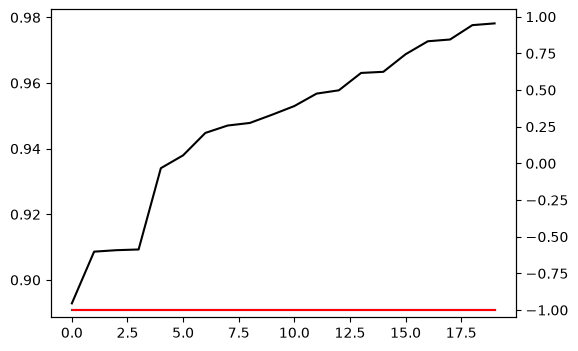

In [166]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

This is not what we expect...

### Factorized cut states

#### Trivial

In [167]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[0]]

In [168]:
factorized_cut_state_sweep_results[0][0]

[np.float32(0.6181309),
 np.float32(2.4286032),
 array([9.99958850e-01, 7.69179222e-04, 7.67772298e-04, 9.86869132e-05,
        9.83236437e-05, 1.80989301e-05, 1.76901912e-05, 1.83300951e-06,
        6.65949521e-07, 4.21238917e-07, 3.75662077e-07, 2.42830098e-07,
        2.15047348e-07, 1.07208130e-07, 6.59011980e-08, 4.11733295e-08]),
 np.complex128(0.9999999701976772+1.6653345369377348e-16j),
 np.complex128(0.999999985098839-3.0733645073333093e-08j),
 np.float64(0.999974681278023)]

In [169]:
all_left_indices = [
    l1[3]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [170]:
all_left_indices

[np.complex128(0.9999999701976772+1.6653345369377348e-16j),
 np.complex128(1.0000001192092902+0j),
 np.complex128(1.0000001192092887+0j),
 np.complex128(1.0000001490116126-1.1102230246251565e-16j),
 np.complex128(0.9999998509883886+2.7755575615628914e-17j),
 np.complex128(0.9999998807907107+0j),
 np.complex128(1.0000000447034838+2.7755575615628914e-17j),
 np.complex128(0.999999806284904-1.1102230246251565e-16j),
 np.complex128(1.0000002086162563+1.1102230246251565e-16j),
 np.complex128(1.000000104308128+1.6653345369377348e-16j),
 np.complex128(0.9999999403953552+1.942890293094024e-16j),
 np.complex128(1+5.551115123125783e-17j),
 np.complex128(0.9999999701976777-2.7755575615628914e-17j),
 np.complex128(0.9999997615814216-4.163336342344337e-17j),
 np.complex128(1.0000001192092896+9.020562075079397e-17j),
 np.complex128(0.9999999552965171+2.7755575615628914e-17j),
 np.complex128(0.9999999105930326-2.7755575615628914e-17j),
 np.complex128(0.9999999701976772+5.551115123125783e-17j),
 np.com

In [171]:
all_right_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [172]:
all_right_indices

[np.complex128(0.999999985098839-3.0733645073333093e-08j),
 np.complex128(1.000000149011612+3.725290353973065e-09j),
 np.complex128(1.0000002235174184+0j),
 np.complex128(1.0000001639127731-2.7939676683352843e-09j),
 np.complex128(0.9999999254941943+4.65661276205509e-09j),
 np.complex128(0.99999988079071+6.519258077819501e-09j),
 np.complex128(1.0000000298023224+1.8626450937198058e-09j),
 np.complex128(0.9999998509883877+7.450580624679404e-09j),
 np.complex128(1.000000223517418-5.587935447692871e-09j),
 np.complex128(1.0000000596046448-9.313226079221693e-09j),
 np.complex128(0.9999998658895493-1.6530975754935895e-08j),
 np.complex128(0.9999999999999998-1.0477378964424133e-09j),
 np.complex128(0.999999940395355+1.2572854868331262e-08j),
 np.complex128(0.9999997317790985-4.6566128730773926e-09j),
 np.complex128(1.000000074505806+5.005858824680409e-09j),
 np.complex128(1.0000000149011612+4.656613011855271e-10j),
 np.complex128(0.9999998509883878+5.551115123125783e-17j),
 np.complex128(0.9

In [173]:
all_overlaps = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [174]:
all_overlaps

[np.float64(0.999974681278023),
 np.float64(0.9999400806569936),
 np.float64(0.999992414978583),
 np.float64(0.9999930221565224),
 np.float64(0.9998327746046158),
 np.float64(0.9999082454516227),
 np.float64(0.9991423069312018),
 np.float64(0.9999964682078778),
 np.float64(0.9999866635497949),
 np.float64(0.9998968124436958),
 np.float64(0.9998595444184284),
 np.float64(0.9999982772690644),
 np.float64(0.9999793467056264),
 np.float64(0.9996099647618163),
 np.float64(0.9999852635907966),
 np.float64(0.9999564337402922),
 np.float64(0.9999604138185353),
 np.float64(0.9999055748529552),
 np.float64(0.9998882544296512),
 np.float64(0.9999006280538218)]

Good overlaps.

#### Nontrivial

In [175]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[1]]

In [176]:
factorized_cut_state_sweep_results[0][0]

[np.float32(0.7665863),
 np.float32(0.67306435),
 array([4.99700492e-01, 2.84755158e-03, 2.17004462e-03, 2.11521828e-03,
        1.11500976e-03, 5.10358616e-04, 2.75203599e-04, 1.97887302e-04,
        1.82973161e-04, 8.10176720e-05, 2.99446902e-05, 2.94710370e-05,
        1.60181541e-05, 3.10497412e-06, 2.95218184e-06, 4.53750301e-07]),
 np.complex128(-0.9999998658895495-8.548717289613705e-15j),
 np.complex128(-0.9999998062849039+6.984933409448502e-09j),
 np.float64(0.9995187670123906)]

In [177]:
all_left_indices = [
    l1[3]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [178]:
all_left_indices

[np.complex128(-0.9999998658895495-8.548717289613705e-15j),
 np.complex128(-1.0000000596046457+0j),
 np.complex128(-1.0000001192092898+0j),
 np.complex128(-1.0000001192092887+7.817424485523361e-11j),
 np.complex128(-0.998118927700921+9.370461653279705e-06j),
 np.complex128(-0.9989732554110771-9.599589392228491e-06j),
 np.complex128(-1.000000201165674-4.3807263372386274e-11j),
 np.complex128(-1.000000014901162+1.3877787807814457e-17j),
 np.complex128(-1.0000001713633542+8.326672684688674e-17j),
 np.complex128(-0.9999999403953546+2.7755575615628914e-17j),
 np.complex128(-0.999999865889549+0j),
 np.complex128(-0.9999999105930331+2.220446049250313e-16j),
 np.complex128(-1.0000001043081295-4.163336342344337e-17j),
 np.complex128(-0.9999999850988389-5.551115123125783e-17j),
 np.complex128(-1.000000119209289+1.1102230246251565e-16j),
 np.complex128(-1.000000029802322+1.6653345369377348e-16j),
 np.complex128(-0.999933045045692+5.6130417864480586e-05j),
 np.complex128(-0.9996618060282567+2.4950

In [179]:
all_right_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [180]:
all_right_indices

[np.complex128(-0.9999998062849039+6.984933409448502e-09j),
 np.complex128(-1.0000000633299349+1.0593794258495492e-08j),
 np.complex128(-1.0000000596046443+1.7462295776038417e-09j),
 np.complex128(-1.0000000894069356+2.6035266165180815e-09j),
 np.complex128(-0.9984389123836678+4.183768923432529e-05j),
 np.complex128(-0.9985727332436607+8.862086798705482e-06j),
 np.complex128(-1.0000002086162076+9.470670192524011e-09j),
 np.complex128(-1.0000000447034834+3.725290464995368e-09j),
 np.complex128(-1.000000178813935-9.313226440044176e-10j),
 np.complex128(-0.9999998807907107+1.6763806398589765e-08j),
 np.complex128(-0.9999999105930333+9.313225746154785e-10j),
 np.complex128(-0.9999999701976775+0j),
 np.complex128(-1.0000000596046446-1.8626451214753814e-09j),
 np.complex128(-0.9999999552965165-5.122274160385132e-09j),
 np.complex128(-1.0000000856816762-7.683411018533093e-09j),
 np.complex128(-0.9999999813735487-8.731149192531262e-09j),
 np.complex128(-0.9999359917887907-1.6001783527119784e-0

In [181]:
all_overlaps = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [182]:
all_overlaps

[np.float64(0.9995187670123906),
 np.float64(0.9996654839831728),
 np.float64(0.999766278743015),
 np.float64(0.9996792281679119),
 np.float64(0.9961902710498268),
 np.float64(0.9972924875974756),
 np.float64(0.9996651352998389),
 np.float64(0.9997620150396652),
 np.float64(0.9997742398745764),
 np.float64(0.9997773660979203),
 np.float64(0.987041235087919),
 np.float64(0.9926537557172903),
 np.float64(0.996809881206072),
 np.float64(0.9974404631787568),
 np.float64(0.9961943672251561),
 np.float64(0.9987241936905913),
 np.float64(0.9966411248985041),
 np.float64(0.9988783706911636),
 np.float64(0.9998903890328326),
 np.float64(0.9999222257170554),
 np.float64(0.9999186472152726),
 np.float64(0.9999126801290329),
 np.float64(0.9994733315614742),
 np.float64(0.9997861322106748),
 np.float64(0.9996214767027047),
 np.float64(0.9998435429900154),
 np.float64(0.9998530007910225),
 np.float64(0.9998210461692334),
 np.float64(0.9998415868770605),
 np.float64(0.9998141633336826),
 np.float64(0

# Conclusions
All working, nice!

# Debugging

In [295]:
fixed_psi = fixed_point_groundstates[1]

In [296]:
rand_psi = apply_haar_random_fdlu_to_quspin_state(fixed_psi)

In [297]:
fixed_psi = fixed_psi[:, 0]

In [298]:
rand_psi.shape

(65536,)

In [299]:
np.linalg.norm(fixed_psi)

np.float64(1.000000000000012)

In [300]:
np.linalg.norm(rand_psi)

np.float64(1.0000000000000022)

In [301]:
np.abs(np.dot(fixed_psi.conj(), rand_psi))

np.float64(0.0035013170953647867)

In [302]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
     0.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1>  65535 
     1.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0>  65534 
     2.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1>  65533 
     3.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0>  65532 
     4.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1>  65531 
     5.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0>  65530 
     6.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1>  65529 
     7.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0>  65528 
     8.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1>  65527 
     9.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0>  65526 
    10.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1>  65525 
    11.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0>  65524 
    12.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1>  65523 
    13.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0>  65522 
    14.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1>  65521 
    15.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0>  65520 
    16.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1>  65519 
    17.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0>  65518 
    18.  |1 1

In [303]:
num_sites

16

In [304]:
symmetry_sites

[4, 5, 6, 7, 8, 9, 10, 11]

In [305]:
fixed_rho = basis.partial_trace(
    fixed_psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [306]:
rand_rho = basis.partial_trace(
    rand_psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

In [307]:
fixed_rho.shape

(256, 256)

In [308]:
type(fixed_rho)

numpy.ndarray

In [309]:
qt_fixed_rho = qtn.Tensor(
    data=fixed_rho.reshape((16, 16, 16, 16,)),
    inds=('kl', 'kr', 'bl', 'br')
)

In [310]:
qt_rand_rho = qtn.Tensor(
    data=rand_rho.reshape((16, 16, 16, 16,)),
    inds=('kl', 'kr', 'bl', 'br')
)

In [311]:
fixed_lr_schmidt_vals = get_left_right_defect_regions_schmidt_vals(qt_fixed_rho)

In [312]:
fixed_lr_schmidt_vals

array([0.25])

In [313]:
rand_lr_schmidt_vals = get_left_right_defect_regions_schmidt_vals(qt_rand_rho)

In [314]:
rand_lr_schmidt_vals

array([0.25, 0.25, 0.25, 0.25])

## Undo FDLU
Fix a random circuit, apply and undo, check we get back original state.

In [315]:
one_site_unitaries = [
    generate_random_symmetry_respecting_unitary()
    for _ in range(num_sites)
]

In [317]:
np.round(one_site_unitaries[0], 3)

array([[-0.795+0.607j,  0.   +0.j   ],
       [ 0.   +0.j   , -0.795-0.607j]])

In [320]:
one_site_unitaries[0]

array([[-7.94678586e-01+0.60703043j,  2.77555756e-16+0.j        ],
       [ 2.77555756e-16+0.j        , -7.94678586e-01-0.60703043j]])

In [318]:
np.round(one_site_unitaries[1], 3)

array([[-0.186-0.983j,  0.   +0.j   ],
       [ 0.   +0.j   , -0.186+0.983j]])

In [319]:
np.round(one_site_unitaries[2], 3)

array([[-0.21+0.978j, -0.  +0.j   ],
       [-0.  +0.j   , -0.21-0.978j]])

In [321]:
np.round(one_site_unitaries[3], 3)

array([[0.   +0.j   , 0.644-0.765j],
       [0.644+0.765j, 0.   +0.j   ]])

In [330]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
     0.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1>  65535 
     1.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0>  65534 
     2.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1>  65533 
     3.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0>  65532 
     4.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1>  65531 
     5.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0>  65530 
     6.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1>  65529 
     7.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0>  65528 
     8.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1>  65527 
     9.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0>  65526 
    10.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1>  65525 
    11.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0>  65524 
    12.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1>  65523 
    13.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0>  65522 
    14.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1>  65521 
    15.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0>  65520 
    16.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1>  65519 
    17.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0>  65518 
    18.  |1 1

In [332]:
help(qtn.TensorNetwork.to_dense)

Help on function to_dense in module quimb.tensor.tensor_core:

to_dense(self, *inds_seq, to_qarray=False, **contract_opts)
    Convert this network into an dense array, with a single dimension
    for each of inds in ``inds_seqs``. E.g. to convert several sites
    into a density matrix: ``TN.to_dense(('k0', 'k1'), ('b0', 'b1'))``.



In [335]:
quimb_one_site_unitaries = [
    qtn.Tensor(u, inds=['k', 'b'])
    for u in one_site_unitaries
]

In [340]:
quimb_one_site_undo_unitaries = [
    u.conj().reindex({'k': 'b', 'b': 'k'})
    for u in quimb_one_site_unitaries
]

In [341]:
qu_fixed_psi = qtn.Tensor(
    fixed_psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

In [342]:
def apply_onsite_unitaries_to_quimb_state(psi, unitaries):
    tn = qtn.TensorNetwork(
        [psi.reindex({f'k{i}': f'b{i}' for i in range(num_sites)}),] +
        [u.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i, u in enumerate(unitaries)],
        virtual=True
    )

    tn.contract(inplace=True)

    return tn

In [343]:
qu_rand_psi = apply_onsite_unitaries_to_quimb_state(
    qu_fixed_psi,
    quimb_one_site_unitaries
)

In [344]:
qu_rand_psi

TensorNetwork(tensors=1, indices=16)

In [351]:
qu_undo_psi = apply_onsite_unitaries_to_quimb_state(
    qu_rand_psi,
    quimb_one_site_undo_unitaries
)

In [352]:
(qu_fixed_psi & qu_fixed_psi.conj()).contract()

np.complex128(1+0j)

In [353]:
(qu_rand_psi & qu_rand_psi.conj()).contract()

np.complex128(1.0000000000000033+0j)

In [354]:
(qu_undo_psi & qu_undo_psi.conj()).contract()

np.complex128(1.0000000000000018+0j)

In [355]:
np.abs((qu_undo_psi & qu_fixed_psi.conj()).contract())

np.float64(0.9999999999999978)

Good!

In [360]:
qu_fixed_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15'), tags=oset([]))

In [364]:
qu_fixed_rho = get_rdm_from_quimb_psi(qu_fixed_psi, symmetry_sites)

In [365]:
qu_fixed_rho

TensorNetwork(tensors=1, indices=16)

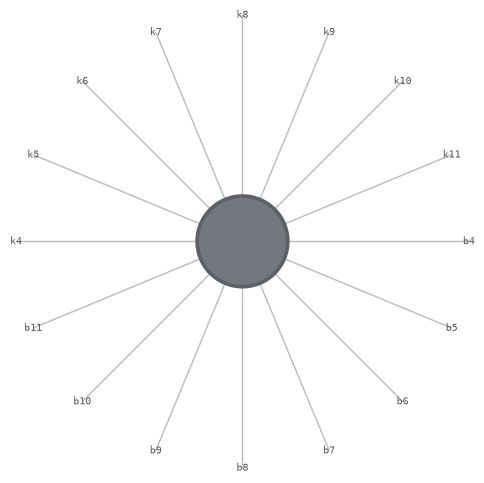

In [366]:
qu_fixed_rho.draw()

In [368]:
qu_fixed_rho.outer_inds()

('k4',
 'k5',
 'k6',
 'k7',
 'k8',
 'k9',
 'k10',
 'k11',
 'b4',
 'b5',
 'b6',
 'b7',
 'b8',
 'b9',
 'b10',
 'b11')

In [389]:
help(qu_fixed_rho.tensors[0].fuse)

Help on method fuse in module quimb.tensor.tensor_core:

fuse(fuse_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Combine groups of indices into single indices.

    Parameters
    ----------
    fuse_map : dict_like or sequence of tuples.
        Mapping like: ``{new_ind: sequence of existing inds, ...}`` or an
        ordered mapping like ``[(new_ind_1, old_inds_1), ...]`` in which
        case the output tensor's fused inds will be ordered. In both cases
        the new indices are created at the minimum axis of any of the
        indices that will be fused.

    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor.



In [390]:
qu_rho_reshaped = (
    qu_fixed_rho
    .tensors[0]
    .fuse({
        'kl': ['k4', 'k5', 'k6', 'k7'],
        'kr': ['k8', 'k9', 'k10', 'k11'],
        'bl': ['b4', 'b5', 'b6', 'b7'],
        'br': ['b8', 'b9', 'b10', 'b11']
    })
)

In [391]:
qu_rho_reshaped

Tensor(shape=(16, 16, 16, 16), inds=('kl', 'kr', 'bl', 'br'), tags=oset([]))

In [387]:
purity = get_purity_from_quimb_rdm(qu_fixed_rho)

In [388]:
purity

0.2499999999999995

In [322]:
def apply_onsite_unitaries_to_quspin_state(psi, unitaries):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for i, u in enumerate(unitaries):
        qu_u = qtn.Tensor(
            u.reshape((2,)*2),
            inds=[f'k{i}', f'b{i}']
        )

        qu_psi = qu_psi.reindex({f'k{i}':  f'b{i}'}) & qu_u
        qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [323]:
rand_psi = apply_onsite_unitaries_to_quspin_state(fixed_psi, one_site_unitaries)
undo_psi = apply_onsite_unitaries_to_quspin_state(
    rand_psi,
    [u.conj().T for u in one_site_unitaries]
)

In [324]:
undo_psi

array([-9.92191564e-05+0.00390499j,  3.79449181e-03+0.0009277j ,
       -2.79439259e-03-0.0027295j , ..., -8.37980182e-04-0.00381531j,
       -1.22011760e-03+0.00371081j,  3.36629569e-03+0.00198163j],
      shape=(65536,))

In [326]:
fixed_psi.shape

(65536,)

In [327]:
np.abs(np.dot(fixed_psi.conj(), undo_psi))

np.float64(0.0009665938145608715)

In [328]:
undo_unitaries = [
    u @ (u.conj().T) for u in one_site_unitaries
]

In [329]:
undo_unitaries

[array([[ 1.00000000e+00+0.00000000e+00j, -4.41135231e-16+3.36969581e-16j],
        [-4.41135231e-16-3.36969581e-16j,  1.00000000e+00+0.00000000e+00j]]),
 array([[ 1.0000000e+00+0.00000000e+00j, -1.0334605e-17-5.45406624e-17j],
        [-1.0334605e-17+5.45406624e-17j,  1.0000000e+00+0.00000000e+00j]]),
 array([[1.00000000e+00+0.00000000e+00j, 5.23636067e-17-2.44250246e-16j],
        [5.23636067e-17+2.44250246e-16j, 1.00000000e+00+0.00000000e+00j]]),
 array([[1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j]]),
 array([[1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j]]),
 array([[ 1.00000000e+00+0.00000000e+00j, -3.21518979e-16+8.69431485e-17j],
        [-3.21518979e-16-8.69431485e-17j,  1.00000000e+00+0.00000000e+00j]]),
 array([[ 1.00000000e+00+0.00000000e+00j, -2.53063902e-17+1.08099668e-16j],
        [-2.53063902e-17-1.08099668e-16j,  1.00000000e+00+0.00000000e+00j]]),
 array([[1.00000000e+00+0.00000000e+00j, 2.56755474e-16+3.62342177e-16j],
        [2.56755474e-16-3.62342177e-16j, 1.00000000e+00+

# Old code

## Test random unitaries

In [51]:
fixed_psi = groundstates[0]

In [52]:
rand_psi = apply_haar_random_fdlu_to_quspin_state(fixed_psi)

In [56]:
fixed_psi.shape

(65536, 1)

In [58]:
fixed_psi = fixed_psi[:, 0]

In [59]:
rand_psi.shape

(65536,)

In [60]:
np.linalg.norm(fixed_psi)

np.float64(1.0000000000000004)

In [61]:
np.linalg.norm(rand_psi)

np.float64(1.0000000000000029)

In [62]:
np.abs(np.dot(fixed_psi.conj(), rand_psi))

np.float64(0.00441890999196327)

In [63]:
qu_fixed_psi = qtn.Tensor(
    fixed_psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

In [64]:
qu_rand_psi = qtn.Tensor(
    rand_psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

In [65]:
qu_fixed_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15'), tags=oset([]))

In [68]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b']
)

In [71]:
qu_X_sym_gates = qtn.TensorNetwork(
    [qu_X.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i in range(num_sites)],
    virtual=True
)

In [74]:
sym_qu_fixed_psi = (
    qu_fixed_psi.conj().reindex({f'k{i}': f'b{i}' for i in range(num_sites)})
    & qu_X_sym_gates
)

sym_qu_fixed_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

In [75]:
(sym_qu_fixed_psi.conj() & sym_qu_fixed_psi).contract()

np.complex128(1+0j)

In [76]:
np.abs((qu_fixed_psi.conj() & sym_qu_fixed_psi).contract())

np.float64(1.0000000000000027)

In [77]:
sym_qu_rand_psi = (
    qu_rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in range(num_sites)})
    & qu_X_sym_gates
)

sym_qu_rand_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

In [78]:
(sym_qu_rand_psi.conj() & sym_qu_rand_psi).contract()

np.complex128(1.0000000000000058+0j)

In [79]:
np.abs((qu_rand_psi.conj() & sym_qu_rand_psi).contract())

np.float64(1.000000000000006)